<a href="https://colab.research.google.com/github/partha2412/Time-Series-Forecast/blob/main/TimeSeries_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
tdf = pd.read_parquet("/content/drive/MyDrive/DBA/Project/demand_forecasting_training.parquet")
tdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
0,S01,SKU_0483,2022-06-01,4,C,0.6
1,S01,SKU_0591,2022-06-01,198,C,0.0
2,S01,SKU_0855,2022-06-01,1366,B,2331.98
3,S01,SKU_1176,2022-06-01,71160,A,42525.27
4,S01,SKU_1378,2022-06-01,2,C,1.63


In [ ]:
tdf.shape

(2945, 6)

In [ ]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2945 entries, 0 to 2944
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Store_ID          2945 non-null   object
 1   SKU_ID            2945 non-null   object
 2   Month             2945 non-null   object
 3   Sales             2945 non-null   object
 4   Category          2945 non-null   object
 5   BaselineForecast  2945 non-null   object
dtypes: object(6)
memory usage: 225.6+ KB


In [ ]:
tdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,object
Sales,object
Category,object
BaselineForecast,object


In [ ]:
vdf = pd.read_parquet("/content/drive/MyDrive/DBA/Project/demand_forecasting_validation.parquet")
vdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
2945,S01,SKU_0483,2025-01-01,0,C,0.63
2946,S01,SKU_0591,2025-01-01,24,C,9.69
2947,S01,SKU_0855,2025-01-01,1324,B,774.5699999999999
2948,S01,SKU_1176,2025-01-01,117246,A,46035.71
2949,S01,SKU_1378,2025-01-01,4,C,2.0700000000000003


In [ ]:
vdf.shape

(475, 6)

In [ ]:
vdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 475 entries, 2945 to 3419
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Store_ID          475 non-null    object
 1   SKU_ID            475 non-null    object
 2   Month             475 non-null    object
 3   Sales             475 non-null    object
 4   Category          475 non-null    object
 5   BaselineForecast  475 non-null    object
dtypes: object(6)
memory usage: 42.1+ KB


In [ ]:
vdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,object
Sales,object
Category,object
BaselineForecast,object


# **Phase 1: Data Acquisition & Initial Exploration**

---
*   Access and load compressed Parquet files (training and validation sets from Azure Blob storage).
*   Clean and preprocess the data.
*   Analyze data characteristics: quantity of SKUs and Stores, SKU types, and general demand patterns etc.

#preprocessing

typecasting training data

In [ ]:
tdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
0,S01,SKU_0483,2022-06-01,4,C,0.6
1,S01,SKU_0591,2022-06-01,198,C,0.0
2,S01,SKU_0855,2022-06-01,1366,B,2331.98
3,S01,SKU_1176,2022-06-01,71160,A,42525.27
4,S01,SKU_1378,2022-06-01,2,C,1.63


In [ ]:
tdf['Sales'] = pd.to_numeric(tdf['Sales'], errors='coerce').fillna(0).astype('float64')
tdf['BaselineForecast'] = pd.to_numeric(tdf['BaselineForecast'], errors='coerce').fillna(0).astype('float64')
tdf['Category'] = tdf["Category"].astype('category')
tdf['Store_ID'] = tdf["Store_ID"].astype('str')
tdf['SKU_ID'] = tdf["SKU_ID"].astype('str')
tdf['Month'] = pd.to_datetime(tdf['Month'])

In [ ]:
tdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,datetime64[ns]
Sales,float64
Category,category
BaselineForecast,float64


typecasting Validation data

In [ ]:
vdf.head()

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
2945,S01,SKU_0483,2025-01-01,0,C,0.63
2946,S01,SKU_0591,2025-01-01,24,C,9.69
2947,S01,SKU_0855,2025-01-01,1324,B,774.5699999999999
2948,S01,SKU_1176,2025-01-01,117246,A,46035.71
2949,S01,SKU_1378,2025-01-01,4,C,2.0700000000000003


In [ ]:
vdf['Sales'] = pd.to_numeric(vdf['Sales'], errors='coerce').fillna(0).astype('float64')
vdf['Category'] = vdf["Category"].astype('category')
vdf['Store_ID'] = vdf["Store_ID"].astype('str')
vdf['SKU_ID'] = vdf["SKU_ID"].astype('str')
vdf['Month'] = pd.to_datetime(vdf['Month'])

In [ ]:
vdf.dtypes

,0
Store_ID,object
SKU_ID,object
Month,datetime64[ns]
Sales,float64
Category,category
BaselineForecast,object


null value check

In [ ]:
tdf.isnull().sum()

,0
Store_ID,0
SKU_ID,0
Month,0
Sales,0
Category,0
BaselineForecast,0


In [ ]:
vdf.isnull().sum()

,0
Store_ID,0
SKU_ID,0
Month,0
Sales,0
Category,0
BaselineForecast,0


duplicated check

In [ ]:
tdf[tdf.duplicated()]

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast


In [ ]:
vdf[vdf.duplicated()]

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast


outliers ?


In [ ]:
tdf.shape

(2945, 6)

In [ ]:
tdf["Sales"].describe()

,Sales
count,2945.000000
mean,14302.898812
std,26746.461595
min,0.000000
25%,2.000000
50%,262.000000
75%,14404.000000
max,147534.000000


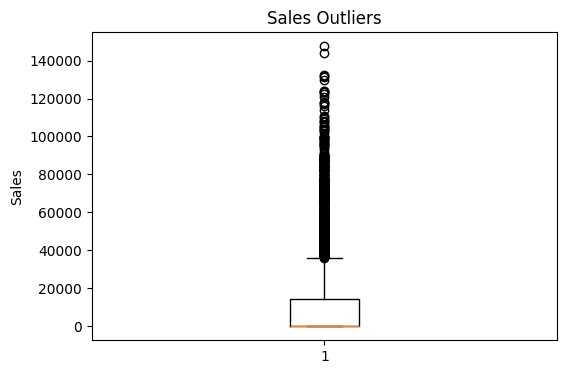

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(tdf["Sales"])
plt.title("Sales Outliers")
plt.ylabel("Sales")
plt.show()

In [ ]:
tdf["Month"].is_monotonic_increasing

False

In [ ]:
Q1 = tdf['Sales'].quantile(0.25)
Q3 = tdf['Sales'].quantile(0.75)
IQR = Q3-Q1
LL = Q1-1.5*IQR
UL = Q3+1.5*IQR

In [ ]:
t_outliers = ((tdf.Sales<LL )| (tdf.Sales>UL))

In [ ]:
print(t_outliers.sum())
print((t_outliers.sum() / len(tdf)) * 100)

568
19.286926994906622


In [ ]:
tdf[t_outliers].head(20)

,Store_ID,SKU_ID,Month,Sales,Category,BaselineForecast
3,S01,SKU_1176,2022-06-01,71160.0,A,42525.27
9,S02,SKU_1176,2022-06-01,53630.0,A,45165.34
11,S03,SKU_1176,2022-06-01,57942.0,A,27153.23
13,S04,SKU_1176,2022-06-01,43779.0,A,20356.75
18,S05,SKU_1176,2022-06-01,36666.0,A,20387.79
42,S11,SKU_1176,2022-06-01,57172.0,A,0.00
45,S12,SKU_1176,2022-06-01,86303.0,A,33271.83
50,S13,SKU_1176,2022-06-01,60106.0,A,30582.79
53,S14,SKU_1176,2022-06-01,57683.0,A,32340.19
58,S15,SKU_1176,2022-06-01,37480.0,A,23301.53


In [ ]:
tdf[t_outliers]["SKU_ID"].value_counts().head(10)

,count
SKU_ID,
SKU_1176,568


In [ ]:
tdf[t_outliers]["Month"].value_counts()

,count
Month,
2024-07-01,19
2024-08-01,19
2024-01-01,18
2024-12-01,18
2024-10-01,18
2023-06-01,18
2022-10-01,17
2022-11-01,17
2022-09-01,17


In [ ]:
tdf[t_outliers]["Category"].value_counts()

,count
Category,
A,568
B,0
C,0


In [ ]:
tdf["SKU_ID"].nunique()

63

In [ ]:
tdf[t_outliers]["Store_ID"].value_counts()

,count
Store_ID,
S01,31
S02,31
S03,31
S04,31
S11,31
S12,31
S25,31
S13,31
S14,31


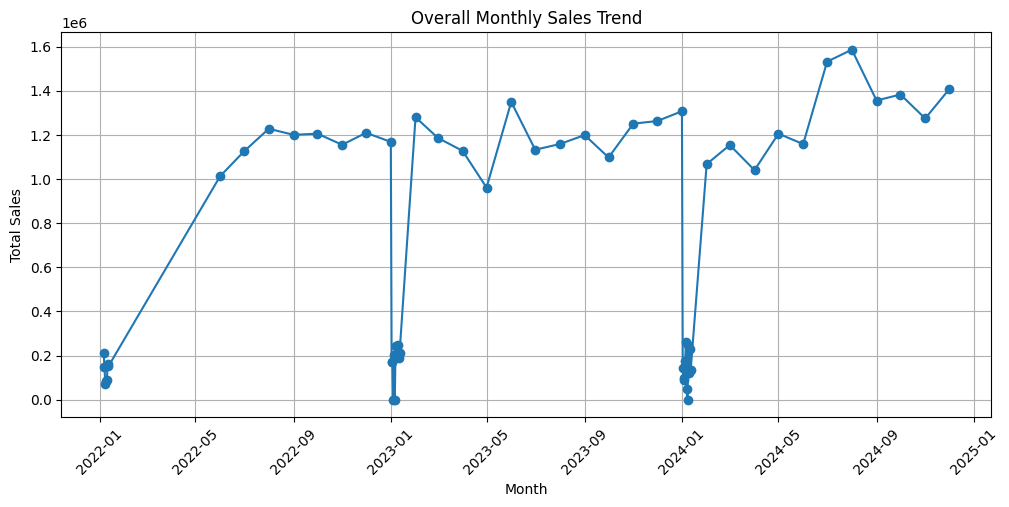

In [ ]:
import matplotlib.pyplot as plt

monthly_sales = tdf.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Overall Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()